In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 한글폰트설정
font_name = 'Gulim'
print(font_name)
plt.rc('font', family=font_name)

df = pd.read_csv('data/구별데이터.csv',encoding='cp949')

df.head(3)

Gulim


,시군구,기초수급자_인구밀도,저소득층_분포비율,총생활인구,총공시지가평균,도시재생사업수,인당녹지면적,초미세먼지,미세먼지,평균기온(°C)
0,강남구,562.481888,0.058183,2.014485e+08,1.225303e+07,0,18673.627282,20.0,37.0,-0.05
1,강동구,929.359319,0.041181,9.498823e+07,3.851911e+06,4,10745.787148,21.0,39.0,-0.45
2,강북구,1608.313995,0.032525,3.995634e+07,2.848680e+06,6,3741.511955,19.0,39.0,-0.25


{'whiskers': [<matplotlib.lines.Line2D at 0x20c8e245070>,
 'caps': [<matplotlib.lines.Line2D at 0x20c8e245610>,
 'boxes': [<matplotlib.lines.Line2D at 0x20c8e676d60>,
 'medians': [<matplotlib.lines.Line2D at 0x20c8e245bb0>,
 'fliers': [<matplotlib.lines.Line2D at 0x20c8e245e80>,
 'means': []}

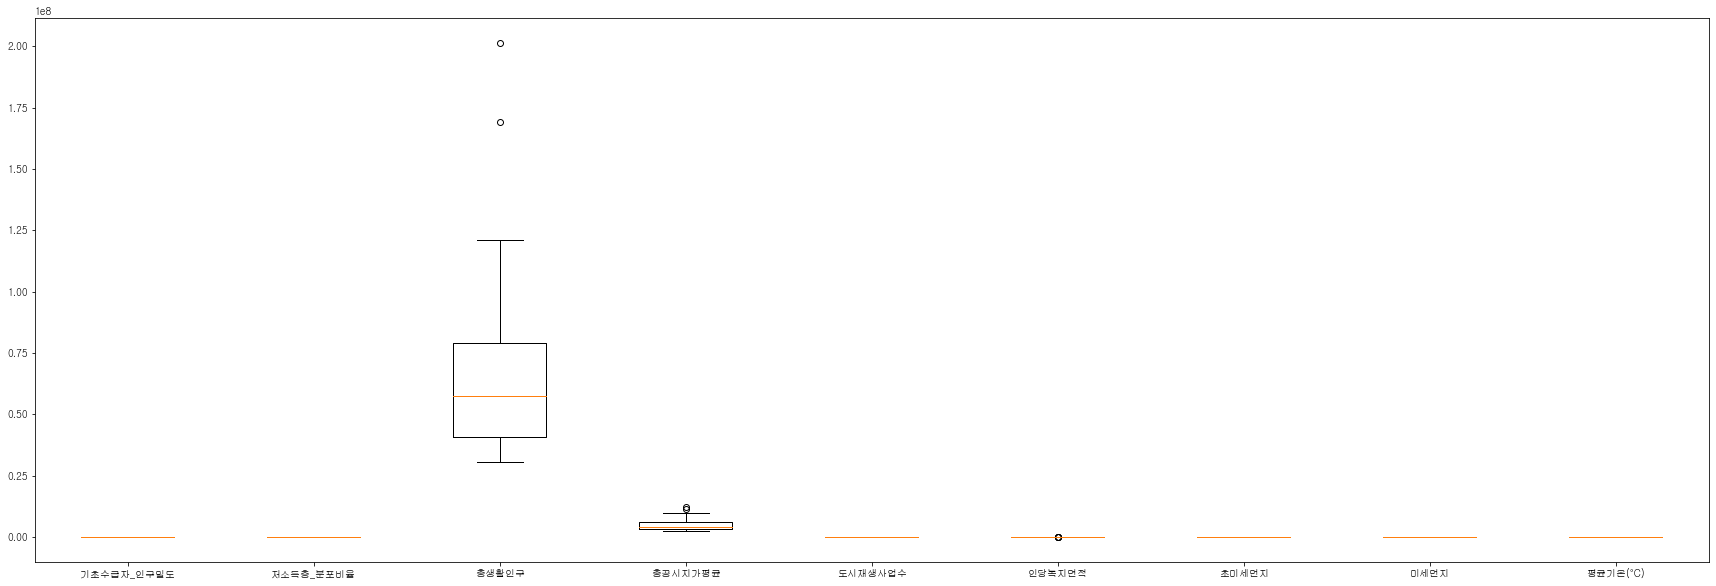

In [7]:
plt.rcParams['figure.figsize'] = (30, 10)

fig=plt.figure() 
ax=fig.add_subplot(1,1,1)
ax.boxplot(df.iloc[:,1:], labels=df.iloc[:,1:].columns)

TypeError: ufunc 'true_divide' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

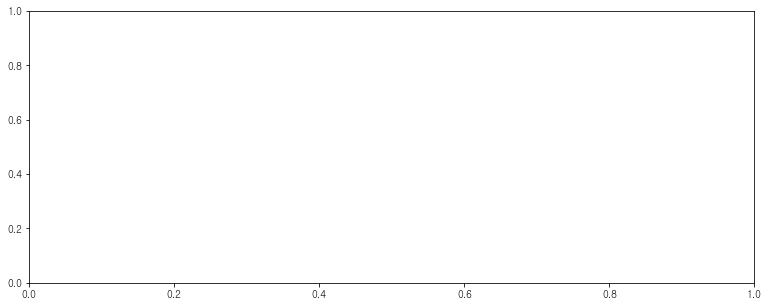

In [38]:
"""from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,1:]) """

import seaborn as sns

plt.rcParams['figure.figsize'] = (40, 10)

fig=plt.figure(figsize=(13, 5)) 
ax=fig.add_subplot(1,1,1)
ax.boxplot(minMaxScaled_data, labels=df.iloc[:,1:].columns)
ax.set_title('구별 데이터 분포')

In [6]:
pd.options.display.float_format = '{:.2f}'.format

In [7]:
df.describe()

,기초수급자_인구밀도,저소득층_분포비율,총생활인구,총공시지가평균,도시재생사업수,인당녹지면적,초미세먼지,미세먼지,평균기온(°C)
count,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00,25.00
mean,928.57,0.04,70930221.76,5090213.53,3.68,9378.50,20.08,38.36,-0.56
std,348.04,0.01,42568559.99,2691848.89,2.54,9521.03,1.08,1.82,1.18
min,198.16,0.01,30595816.41,2565664.80,0.00,312.06,18.00,35.00,-3.05
25%,709.38,0.03,40516352.87,3153749.59,2.00,3985.84,19.00,37.00,-1.35
50%,916.62,0.04,57470625.76,4194807.33,4.00,5500.79,20.00,38.00,-0.20
75%,1195.02,0.05,79115627.25,6172999.97,6.00,9588.58,21.00,40.00,0.30
max,1608.31,0.06,201448520.05,12253031.75,10.00,43885.47,22.00,42.00,1.90


In [ ]:
import dataframe_image as dfi

dfi.export(df.describe(), './image/info_구별데이터.png', max_cols = -1, max_rows = -1)

C:\Users\user\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='총공시지가평균', ylabel='Density'>

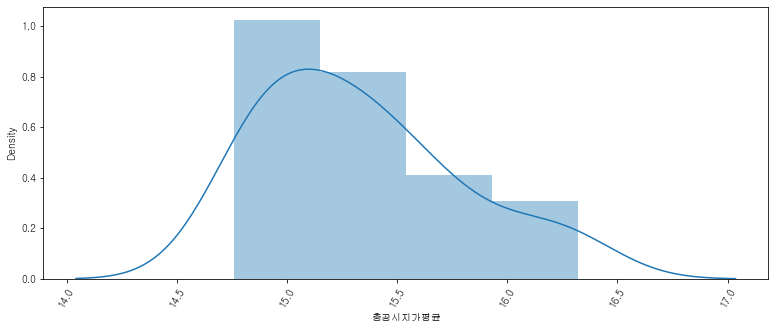

In [35]:
fig=plt.figure(figsize=(13, 5))
plt.xticks(rotation=60)
sns.distplot(df['총공시지가평균'])

In [36]:
fig.savefig("image/구별데이터_공시지가_로그변환분포.png")

In [ ]:
df[df.저소득층_비율 == df.저소득층_비율.max()]

In [ ]:
df[df.기초수급자_인구밀도 == df.기초수급자_인구밀도.max()]

In [ ]:
df[df.총생활인구 == df.총생활인구.max()]

In [ ]:
df[df.인당녹지면적 == df.인당녹지면적.max()]

In [ ]:
df[df.총공시지가평균 == df.총공시지가평균.max()]

In [25]:
import numpy as np
df['인당녹지면적'] = np.log1p(df['인당녹지면적'])
df['총생활인구'] = np.log1p(df['총생활인구'])
df['총공시지가평균'] = np.log1p(df['총공시지가평균'])

In [ ]:
sns.distplot(df['인당녹지면적'])

In [ ]:
sns.distplot(df['총생활인구'])

In [ ]:
sns.distplot(df['총공시지가평균'])

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minMaxScaler = MinMaxScaler()
minMaxScaled_data = minMaxScaler.fit_transform(df.iloc[:,1:]) 

In [ ]:
data_df = pd.DataFrame(minMaxScaled_data,columns = df.iloc[:,1:].columns.to_list())
data_df

In [ ]:
df_scale = pd.concat([df.iloc[:,:1],data_df], axis=1)

In [ ]:
df_scale.to_csv('data/정제데이터/구별데이터_스케일링.csv',encoding='cp949',index=False)